In [1]:
import argparse
import yaml
from multiprocessing import cpu_count
import torch.multiprocessing as mp
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Repo-specific imports
# -------------------------------------------------------------------
# import sys 
# print(sys.path)
from globals import REPO_ROOT, TOOLS_DIR

from MAST_benchmark.tools.utils import get_device
from MAST_benchmark.data_split import get_train_test_val_shots
from MAST_benchmark.tasks import get_task_config, get_task_metadata
from MAST_benchmark.tools.transforms.compose_transform import (
    ComposeTransforms,
)
from MAST_benchmark.data import (
    initialize_MAST_dataset, initialize_model_dataset
)

from timecnn_transform import (
    TimeCNNTransform,
)

from cnn_utils import (
    cnn_training_collate_fn,
    create_cnn_architecture,
    loop_for_cnn_training,
    cnn_evaluation_per_shot,
    cnn_save_traces_per_shot,
)

# Set device
device = get_device()
# print(f"Using device: {device}\n")

In [2]:
print(f"Number of available CPU cores: {cpu_count()}\n")
mp.set_start_method("spawn", force=True)

# -------------------------------------------------------------------
# Argument parsing
# -------------------------------------------------------------------
parser = argparse.ArgumentParser()
parser.add_argument(
    "--task",
    type=str,
    default="task_4-1",
    help="The name of the task available in the benchmark",
)
parser.add_argument(
    "--config_cnn",
    type=str,
    default="/config_cnn_reconstruction.yaml",
    help="Path to the model YAML config file",
)
args, _ = parser.parse_known_args()

# Load Task YAML config
config_task = get_task_config(args.task)    

# Load CNN YAML config
with open(REPO_ROOT + args.config_cnn, "r") as f:
    config_cnn = yaml.safe_load(f)


Number of available CPU cores: 76



In [3]:
# -------------------------------------------------------------------
# Initialize task-specific metadata
# -------------------------------------------------------------------

dict_task_metadata = get_task_metadata(
    config_task,
    verbose=False
)

In [ ]:
# -------------------------------------------------------------------
# Initialize MAST datasets
# -------------------------------------------------------------------

train_shots_, test_shots_, val_shots_ = get_train_test_val_shots(
    max_index=config_cnn["subset_of_shots"]
)

local_flag = config_cnn["local"]

train_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    train_shots_,
    local_flag = local_flag,
    use_std_scaling = True,
    return_incomplete_shots=True
)
print("len(train_MAST_dataset) is ", len(train_MAST_dataset))

val_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    val_shots_,
    local_flag = local_flag,
    use_std_scaling = True,
    return_incomplete_shots=True
)

test_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    test_shots_,
    local_flag = local_flag,
    use_std_scaling = False,
    return_incomplete_shots=True
)


len(train_MAST_dataset) is  9259


In [5]:
def get_idx(MAST_dataset, shot_id):
    return(MAST_dataset.shots_list.index(shot_id))

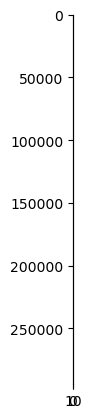

In [24]:
# shot_idx = get_idx(test_MAST_dataset, 30428)
shot_idx = get_idx(train_MAST_dataset, 29562)
var = 'soft_x_rays-horizontal_cam_upper'
data = test_MAST_dataset[shot_idx][var]
plt.plot( data['values'].T )
plt.imshow( data['values'].T )


In [25]:
data['values'].T[:100].shape

(100, 18)

In [39]:
50000/7

7142.857142857143

In [42]:
import numpy as np

np.unique(data['values'][0])

array([-0.00289917, -0.00274658, -0.00259399, -0.00244141, -0.00228882,
       -0.00213623, -0.00198364, -0.00183105, -0.00167847, -0.00152588,
       -0.00137329, -0.0012207 , -0.00106812, -0.00091553, -0.00076294,
       -0.00061035, -0.00045776, -0.00030518, -0.00015259,  0.        ,
        0.00015259,  0.00030518,  0.00045776,  0.00061035,  0.00076294,
        0.00091553,  0.0012207 ,  0.00137329,  0.00152588,  0.00167847,
        0.00183105,  0.00198364,         nan])

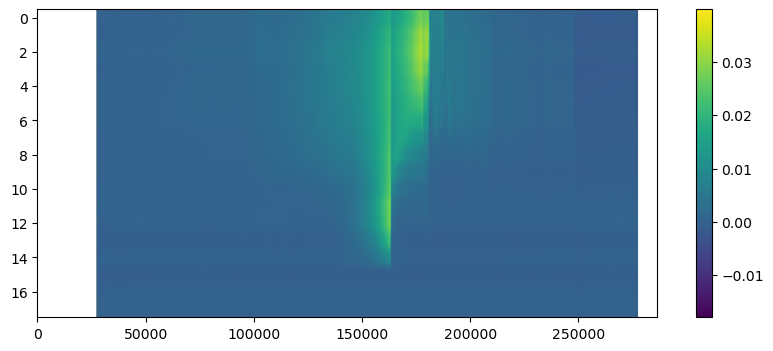

In [44]:
# shot_idx = get_idx(train_MAST_dataset, 29562)
shot_idx = 0
var = 'soft_x_rays-horizontal_cam_upper'
data = test_MAST_dataset[shot_idx][var]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))  # width, height in inches

plt.imshow( data['values'].T[:].T, aspect='auto')
plt.colorbar()

plt.show()

In [ ]:
test_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    test_shots_,
    local_flag = local_flag,
    use_std_scaling = True,
    return_incomplete_shots=True
)

# shot_idx = get_idx(train_MAST_dataset, 29562)

for shot_idx in range(0, 10):

    var = 'soft_x_rays-horizontal_cam_upper'
    data = test_MAST_dataset[shot_idx][var]

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))  # width, height in inches

    plt.imshow( data['values'].T[:].T, aspect='auto')
    plt.colorbar()

    plt.show()

KeyError: 'thomson_scattering-n_e'

In [49]:
import pickle 

metadata_path = '/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/fairmast-data-preprocessing/src/MAST_benchmark/metadata/dict_metadata.pkl'
with open(metadata_path, "rb") as f:  # 'rb' = read binary
    dict_metadata = pickle.load(f)

In [57]:
for var in dict_metadata.keys():
    print(f"\n{var}")
    print(dict_metadata[var]['mean'][0])


magnetics-flux_loop_flux
-0.24482304754028

magnetics-b_field_pol_probe_ccbv_field
0.0862491938215626

magnetics-b_field_pol_probe_obr_field
-0.005725026059536219

magnetics-b_field_pol_probe_obv_field
-0.023211025438189918

magnetics-b_field_tor_probe_saddle_voltage
0.08051750618705385

magnetics-b_field_tor_probe_cc_field
-9.856565755788336e-07

magnetics-b_field_pol_probe_omv_voltage
-0.003774836061001681

pf_active-coil_voltage
18.474549171449517

pf_active-coil_current
656.9949197066564

pf_active-solenoid_current
-2744.0386362009635

pulse_schedule-i_plasma
442211.25025095796

pulse_schedule-n_e_line
5.40282351776181e+19

interferometer-n_e_line
8.066135723905117e+19

summary-power_nbi
710985.970125848

summary-ip
348384.37991593697

gas_injection-total_injected
2.515241466878821e+21

equilibrium-psi
[-0.02211782 -0.02211782 -0.02211782 -0.02211782 -0.02211782 -0.02211782
 -0.02211782 -0.02211782 -0.02211782 -0.02211782 -0.02211782 -0.02211782
 -0.02211782 -0.02211782 -0.0221178

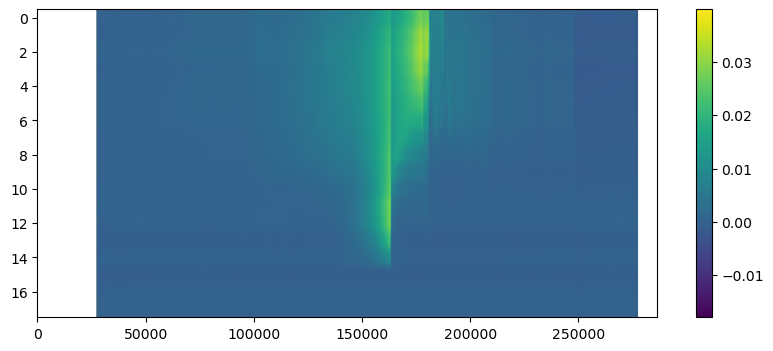

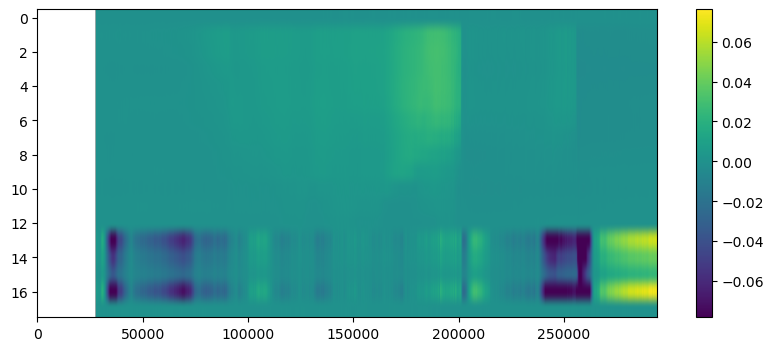

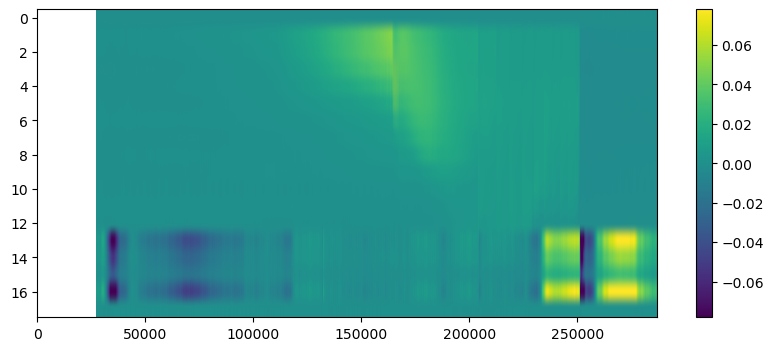

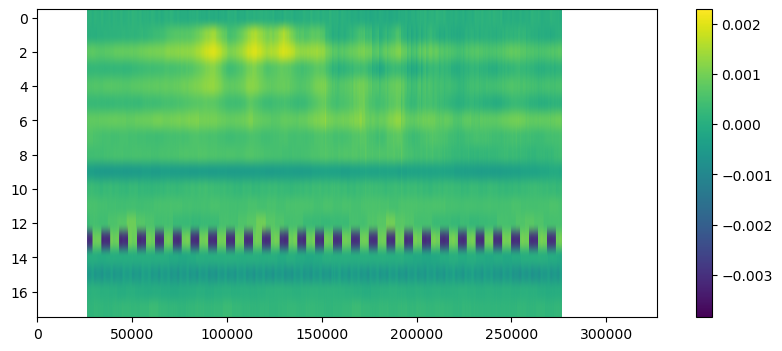

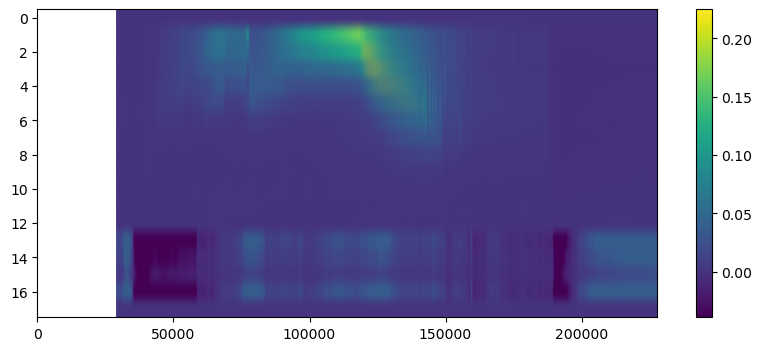

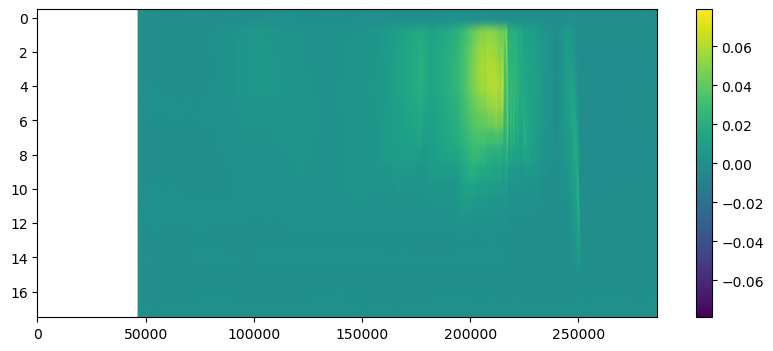

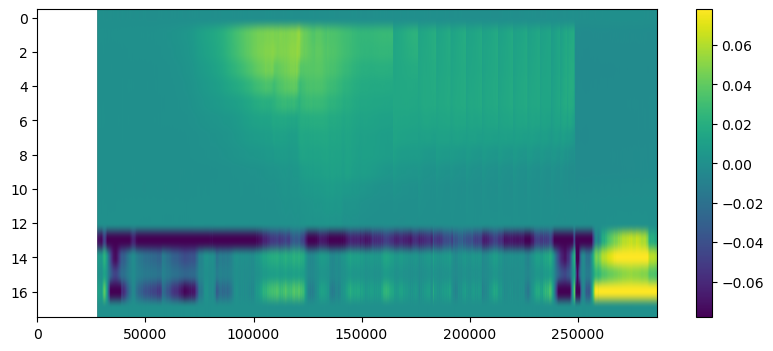

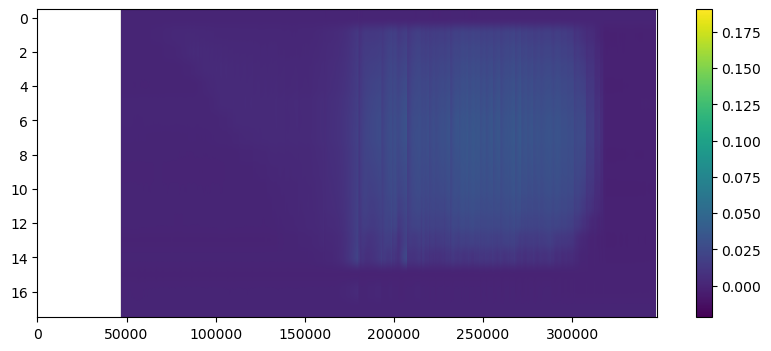

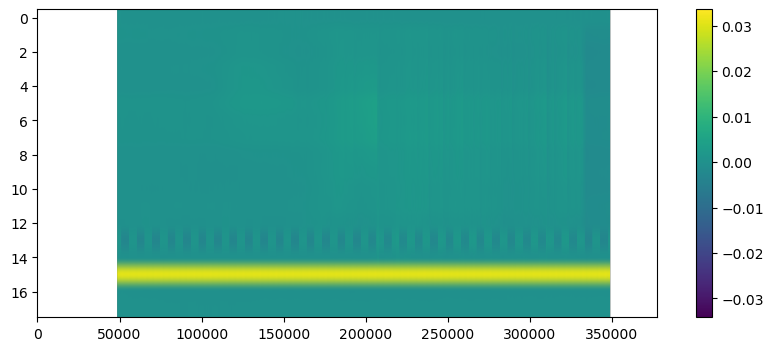

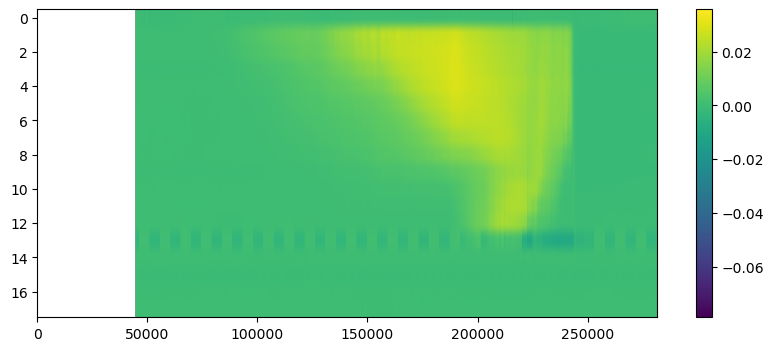

In [46]:
# shot_idx = get_idx(train_MAST_dataset, 29562)

for shot_idx in range(0, 10):

    var = 'soft_x_rays-horizontal_cam_upper'
    data = test_MAST_dataset[shot_idx][var]

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))  # width, height in inches

    plt.imshow( data['values'].T[:].T, aspect='auto')
    plt.colorbar()

    plt.show()

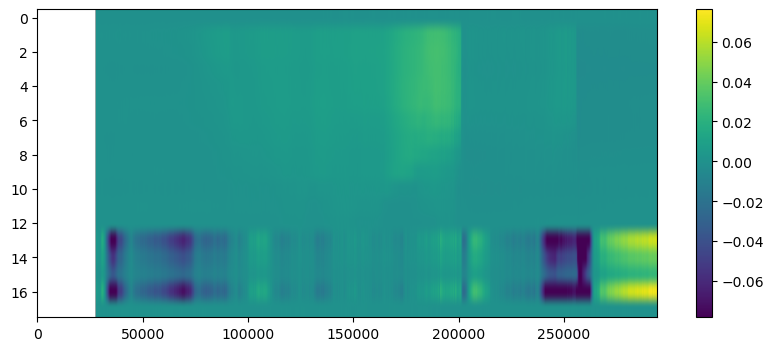

In [45]:
shot_idx = get_idx(train_MAST_dataset, 29562)
var = 'soft_x_rays-horizontal_cam_upper'
data = test_MAST_dataset[shot_idx][var]

plt.figure(figsize=(10, 4))  # width, height in inches

plt.imshow( data['values'].T[:].T, aspect='auto')
plt.colorbar()

plt.show()

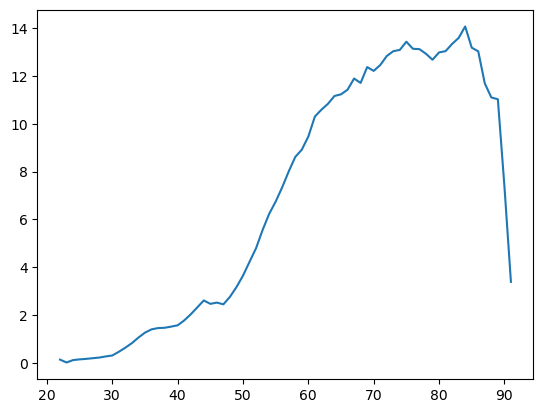

In [30]:
plt.plot( data['values'].T )

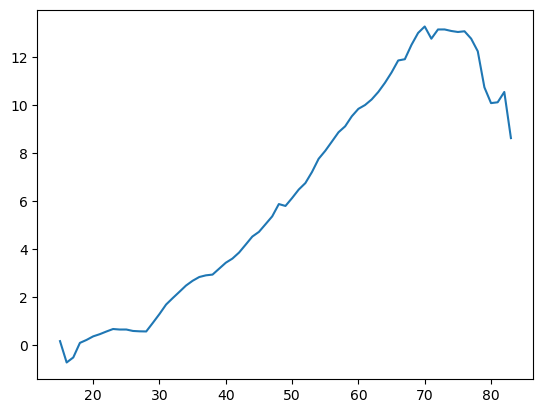

In [32]:
shot_idx = get_idx(test_MAST_dataset, 30428)
# shot_idx = get_idx(test_MAST_dataset, 14497)
var = 'equilibrium-beta_tor'
data = test_MAST_dataset[shot_idx][var]
plt.plot( data['values'].T )

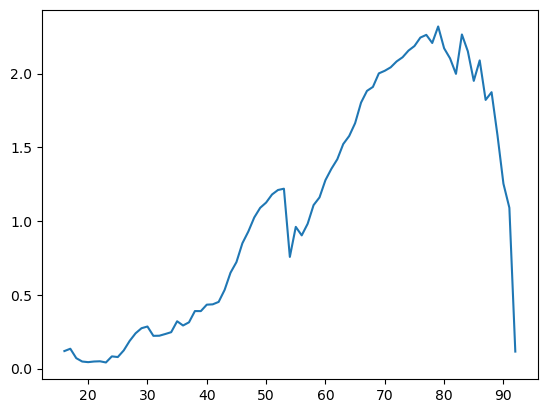

In [33]:
# non problematic

# shot_idx = get_idx(test_MAST_dataset, 30428)
shot_idx = get_idx(test_MAST_dataset, 14497)
var = 'equilibrium-beta_tor'
data = test_MAST_dataset[shot_idx][var]
plt.plot( data['values'].T )

In [ ]:
# -------------------------------------------------------------------
# CNN pipeline
# -------------------------------------------------------------------

model_specific_transform = ComposeTransforms(
    [
        TimeCNNTransform(dict_task_metadata),
    ]
)

train_dataset = initialize_model_dataset(
    train_MAST_dataset, dict_task_metadata, config_task, model_specific_transform
)
train_dataloader = DataLoader(
        dataset=train_dataset,
        collate_fn=cnn_training_collate_fn,
        **config_cnn["dataloader_setting"]
    )

val_dataset = initialize_model_dataset(
    val_MAST_dataset, dict_task_metadata, config_task, model_specific_transform
)
val_dataloader = DataLoader(
        dataset=val_dataset,
        collate_fn=cnn_training_collate_fn,
        **config_cnn["dataloader_setting"]
    )

test_dataset = initialize_model_dataset(
    test_MAST_dataset, dict_task_metadata, config_task, model_specific_transform
)
test_dataloader = DataLoader(
        dataset=test_dataset,
        collate_fn=cnn_training_collate_fn,
        **config_cnn["dataloader_setting"]
    )

cnn_model = create_cnn_architecture(
    train_dataloader, **config_cnn["cnn_settings"], verbose=True
)

# -------------------------------------------------------------------
# Training loop
# -------------------------------------------------------------------
best_model_state, early_stop = loop_for_cnn_training(
    base_cnn_model=cnn_model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    **config_cnn["training_args"],
    output_dir=REPO_ROOT
    + config_cnn["paths"]["data_output_directory"] 
    + config_task["task_name"]
    + "/",
    verbose=True,
)

# -------------------------------------------------------------------
# Evaluation loop
# -------------------------------------------------------------------

cnn_evaluation_per_shot(test_dataloader, config_task, cnn_model, config_cnn)

cnn_save_traces_per_shot(
    test_dataloader, config_task, cnn_model, config_cnn, n_traces=10
)
